# Value-Bin-by-Delay MVPA — Aggregate Results

Loads outputs from the three Slurm jobs (one per delay bin) and summarises:
1. ROI availability and subject/voxel counts
2. Balanced accuracy vs chance per ROI x delay bin
3. Per-class AUC (A1/A2/A3)
4. Per-class precision / recall / F1
5. Confusion matrices
6. Subject-level prediction summaries

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dd_kable_analysis.config_loader import load_config

cfg = load_config()

ANALYSIS_TAG = 'value_bins_by_delay_pauli_rois'
RESULTS_ROOT = Path(cfg.output_root) / f'mvpa_{ANALYSIS_TAG}'
DELAY_BINS = [1, 2, 3]
DELAY_LABELS = {1: 'D1 (short)', 2: 'D2 (mid)', 3: 'D3 (long)'}
CHANCE = 1 / 3

PAULI_LABELS = {
    1: 'Pu',
    2: 'Ca',
    3: 'NAC',
    4: 'EXA',
    5: 'GPe',
    6: 'GPi',
    7: 'SNc',
    8: 'RN',
    9: 'SNr',
    10: 'PBP',
    11: 'VTA',
    12: 'VeP',
    13: 'HN',
    14: 'HTH',
    15: 'MN',
    16: 'STH',
}

print('Results root:', RESULTS_ROOT)
for d in DELAY_BINS:
    p = RESULTS_ROOT / f'delay_bin_{d}'
    success = (p / '_SUCCESS').exists()
    print(f'  delay_bin={d}: {"OK" if success else "NOT DONE"}')

Results root: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_value_bins_by_delay_pauli_rois
  delay_bin=1: OK
  delay_bin=2: OK
  delay_bin=3: OK


---
## 1. Load outputs

In [2]:
roi_summary_parts = []
subject_preds_parts = []
confusion_parts = []
meta_all = {}

for d in DELAY_BINS:
    d_dir = RESULTS_ROOT / f'delay_bin_{d}'
    if not (d_dir / '_SUCCESS').exists():
        print(f'delay_bin={d} not complete, skipping')
        continue
    roi_summary_parts.append(pd.read_csv(d_dir / 'roi_summary.csv'))
    subject_preds_parts.append(pd.read_csv(d_dir / 'subject_preds.csv'))
    confusion_parts.append(pd.read_csv(d_dir / 'confusion_matrix.csv'))
    meta_all[d] = json.loads((d_dir / 'meta.json').read_text())

roi_df = pd.concat(roi_summary_parts, ignore_index=True)
pred_df = pd.concat(subject_preds_parts, ignore_index=True)
conf_df = pd.concat(confusion_parts, ignore_index=True)

roi_df['roi_name'] = roi_df['roi_label'].map(PAULI_LABELS)
pred_df['roi_name'] = pred_df['roi_label'].map(PAULI_LABELS)
conf_df['roi_name'] = conf_df['roi_label'].map(PAULI_LABELS)

print(f'roi_df shape:  {roi_df.shape}')
print(f'pred_df shape: {pred_df.shape}')
print(f'conf_df shape: {conf_df.shape}')
roi_df.head()

roi_df shape:  (9, 22)
pred_df shape: (3231, 10)
conf_df shape: (81, 6)


,roi_label,delay_bin,n_subjects,n_patterns,n_vox,chance_level,accuracy,balanced_accuracy,mean_C,precision_A1,...,auc_A1,precision_A2,recall_A2,f1_A2,auc_A2,precision_A3,recall_A3,f1_A3,auc_A3,roi_name
0,1,1,120,360,1306,0.333333,0.338889,0.338889,0.000100,0.316832,...,0.466806,0.350515,0.283333,0.313364,0.496944,0.345679,0.466667,0.397163,0.480312,Pu
1,2,1,120,360,1272,0.333333,0.313889,0.313889,0.000100,0.352459,...,0.532257,0.272727,0.200000,0.230769,0.462118,0.306667,0.383333,0.340741,0.460833,Ca
2,14,1,119,357,34,0.333333,0.341737,0.341737,0.000823,0.360902,...,0.507309,0.324561,0.310924,0.317597,0.510381,0.336364,0.310924,0.323144,0.520938,HTH
3,1,2,120,360,1306,0.333333,0.375000,0.375000,0.000100,0.389262,...,0.546181,0.373239,0.441667,0.404580,0.519514,0.347826,0.200000,0.253968,0.458785,Pu
4,2,2,120,360,1272,0.333333,0.338889,0.338889,0.000100,0.310680,...,0.490347,0.356061,0.391667,0.373016,0.532674,0.344000,0.358333,0.351020,0.540208,Ca


---
## 2. QC: subject and voxel counts per ROI x delay bin

In [3]:
print('Subject counts per ROI x delay bin:')
print(
    roi_df.pivot_table(
        index='roi_name', columns='delay_bin', values='n_subjects', aggfunc='first'
    )
    .fillna('-')
    .to_string()
)
print()
print('Voxel counts (post-intersection) per ROI x delay bin:')
print(
    roi_df.pivot_table(
        index='roi_name', columns='delay_bin', values='n_vox', aggfunc='first'
    )
    .fillna('-')
    .to_string()
)

Subject counts per ROI x delay bin:
delay_bin    1    2    3
roi_name                
Ca         120  120  120
HTH        119  119  119
Pu         120  120  120

Voxel counts (post-intersection) per ROI x delay bin:
delay_bin     1     2     3
roi_name                   
Ca         1272  1272  1272
HTH          34    34    34
Pu         1306  1306  1306


In [4]:
for d, meta in meta_all.items():
    print(f'--- delay_bin={d} ---')
    print(f'  delay edges: {meta["bin_edges"]["delay_edges"]}')
    print(f'  value edges: {meta["bin_edges"]["value_edges"]}')
    sc = meta['subject_counts']
    print(
        f'  subjects: requested={sc["n_subjects_requested"]}  '
        f'beh_ok={sc["n_subjects_beh_ok"]}  '
        f'binned_ok={sc["n_subjects_binned_ok"]}  '
        f'with_delay_bin={sc["n_subjects_with_delay_bin"]}'
    )
    if sc['failed_beh']:
        print(f'  failed beh: {sc["failed_beh"]}')
    if sc['failed_binned']:
        print(f'  failed binned: {sc["failed_binned"]}')
    print()

--- delay_bin=1 ---
  delay edges: [74.0, 128.0]
  value edges: [35.0, 58.0]
  subjects: requested=123  beh_ok=122  binned_ok=122  with_delay_bin=120
  failed beh: ['dmp0063']

--- delay_bin=2 ---
  delay edges: [74.0, 128.0]
  value edges: [35.0, 58.0]
  subjects: requested=123  beh_ok=122  binned_ok=122  with_delay_bin=120
  failed beh: ['dmp0063']

--- delay_bin=3 ---
  delay edges: [74.0, 128.0]
  value edges: [35.0, 58.0]
  subjects: requested=123  beh_ok=122  binned_ok=122  with_delay_bin=120
  failed beh: ['dmp0063']



---
## 3. Balanced accuracy vs chance

Primary summary metric. Chance = 0.333.

In [5]:
print(f'Balanced accuracy (chance = {CHANCE:.3f}):')
print(
    roi_df.pivot_table(
        index='roi_name', columns='delay_bin', values='balanced_accuracy'
    )
    .round(3)
    .to_string()
)

Balanced accuracy (chance = 0.333):
delay_bin      1      2      3
roi_name                      
Ca         0.314  0.339  0.322
HTH        0.342  0.311  0.347
Pu         0.339  0.375  0.369


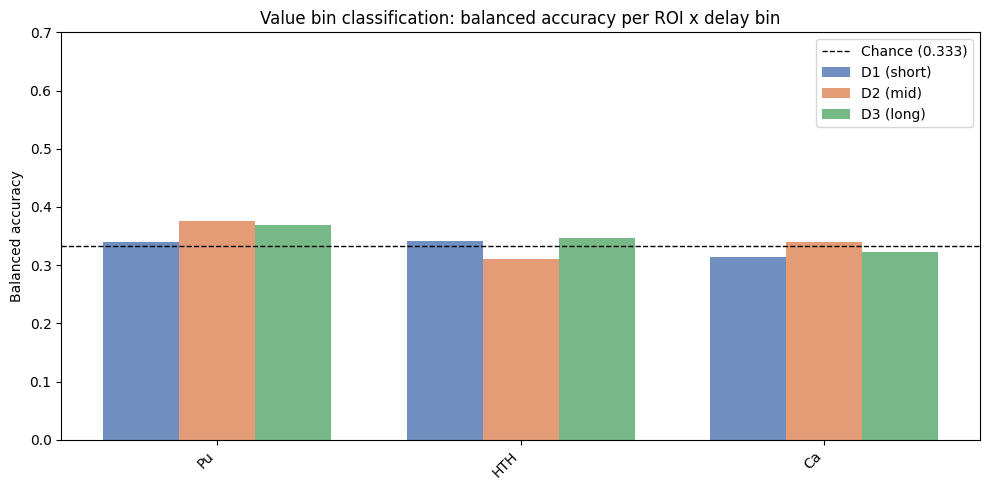

In [6]:
roi_order = (
    roi_df.groupby('roi_name')['balanced_accuracy']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(roi_order))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, d in enumerate(DELAY_BINS):
    subset = roi_df[roi_df['delay_bin'] == d].set_index('roi_name')
    vals = [
        subset.loc[r, 'balanced_accuracy'] if r in subset.index else np.nan
        for r in roi_order
    ]
    ax.bar(
        x + i * width, vals, width, label=DELAY_LABELS[d], color=colors[i], alpha=0.8
    )

ax.axhline(CHANCE, color='k', linestyle='--', linewidth=1, label='Chance (0.333)')
ax.set_xticks(x + width)
ax.set_xticklabels(roi_order, rotation=45, ha='right')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Value bin classification: balanced accuracy per ROI x delay bin')
ax.legend()
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

---
## 4. Per-class AUC (one-vs-rest)

Threshold-free discriminability. A1 = low value, A2 = mid, A3 = high. Chance = 0.5.

In [7]:
for vbin, label in [('A1', 'low value'), ('A2', 'mid value'), ('A3', 'high value')]:
    col = f'auc_{vbin}'
    pivot = roi_df.pivot_table(index='roi_name', columns='delay_bin', values=col).round(
        3
    )
    print(f'AUC {vbin} ({label}) — chance = 0.5:')
    print(pivot.to_string())
    print()

AUC A1 (low value) — chance = 0.5:
delay_bin      1      2      3
roi_name                      
Ca         0.532  0.490  0.510
HTH        0.507  0.475  0.506
Pu         0.467  0.546  0.536

AUC A2 (mid value) — chance = 0.5:
delay_bin      1      2      3
roi_name                      
Ca         0.462  0.533  0.436
HTH        0.510  0.518  0.505
Pu         0.497  0.520  0.487

AUC A3 (high value) — chance = 0.5:
delay_bin      1      2      3
roi_name                      
Ca         0.461  0.540  0.495
HTH        0.521  0.498  0.489
Pu         0.480  0.459  0.549



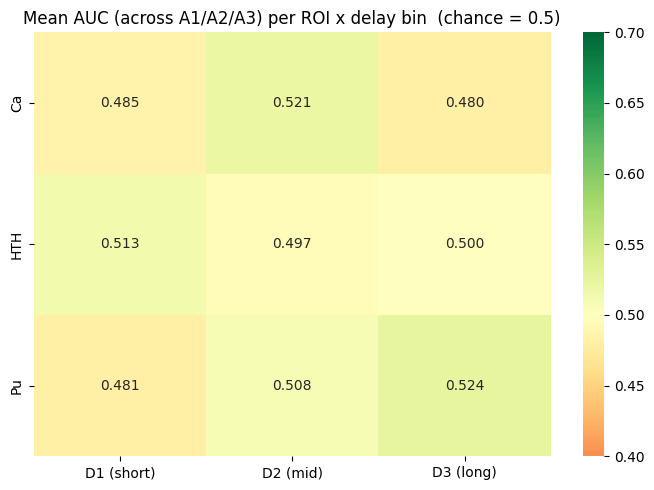

In [8]:
auc_cols = ['auc_A1', 'auc_A2', 'auc_A3']
roi_df['mean_auc'] = roi_df[auc_cols].mean(axis=1)

pivot_auc = roi_df.pivot_table(index='roi_name', columns='delay_bin', values='mean_auc')
pivot_auc.columns = [DELAY_LABELS[c] for c in pivot_auc.columns]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_auc,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.4,
    vmax=0.7,
    center=0.5,
    ax=ax,
)
ax.set_title('Mean AUC (across A1/A2/A3) per ROI x delay bin  (chance = 0.5)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 5. Per-class precision / recall / F1

Checks whether the classifier is collapsing to one class.

In [9]:
for metric in ['precision', 'recall', 'f1']:
    print(f'=== {metric.upper()} ===')
    for vbin in ['A1', 'A2', 'A3']:
        col = f'{metric}_{vbin}'
        pivot = roi_df.pivot_table(
            index='roi_name', columns='delay_bin', values=col
        ).round(3)
        print(f'  {vbin}:')
        print(pivot.to_string())
    print()

=== PRECISION ===
  A1:
delay_bin      1      2      3
roi_name                      
Ca         0.352  0.311  0.340
HTH        0.361  0.282  0.349
Pu         0.317  0.389  0.386
  A2:
delay_bin      1      2      3
roi_name                      
Ca         0.273  0.356  0.270
HTH        0.325  0.343  0.346
Pu         0.351  0.373  0.325
  A3:
delay_bin      1      2      3
roi_name                      
Ca         0.307  0.344  0.339
HTH        0.336  0.299  0.346
Pu         0.346  0.348  0.396

=== RECALL ===
  A1:
delay_bin      1      2      3
roi_name                      
Ca         0.358  0.267  0.450
HTH        0.403  0.244  0.429
Pu         0.267  0.483  0.450
  A2:
delay_bin      1      2      3
roi_name                      
Ca         0.200  0.392  0.200
HTH        0.311  0.395  0.303
Pu         0.283  0.442  0.308
  A3:
delay_bin      1      2      3
roi_name                      
Ca         0.383  0.358  0.317
HTH        0.311  0.294  0.311
Pu         0.467  0.200  0.350


---
## 6. Confusion matrices

Colour = row-normalised rate; number = raw count.
Errors concentrated on adjacent bins (A1<->A2, A2<->A3) suggest ordinal encoding
even when overall accuracy is near chance.

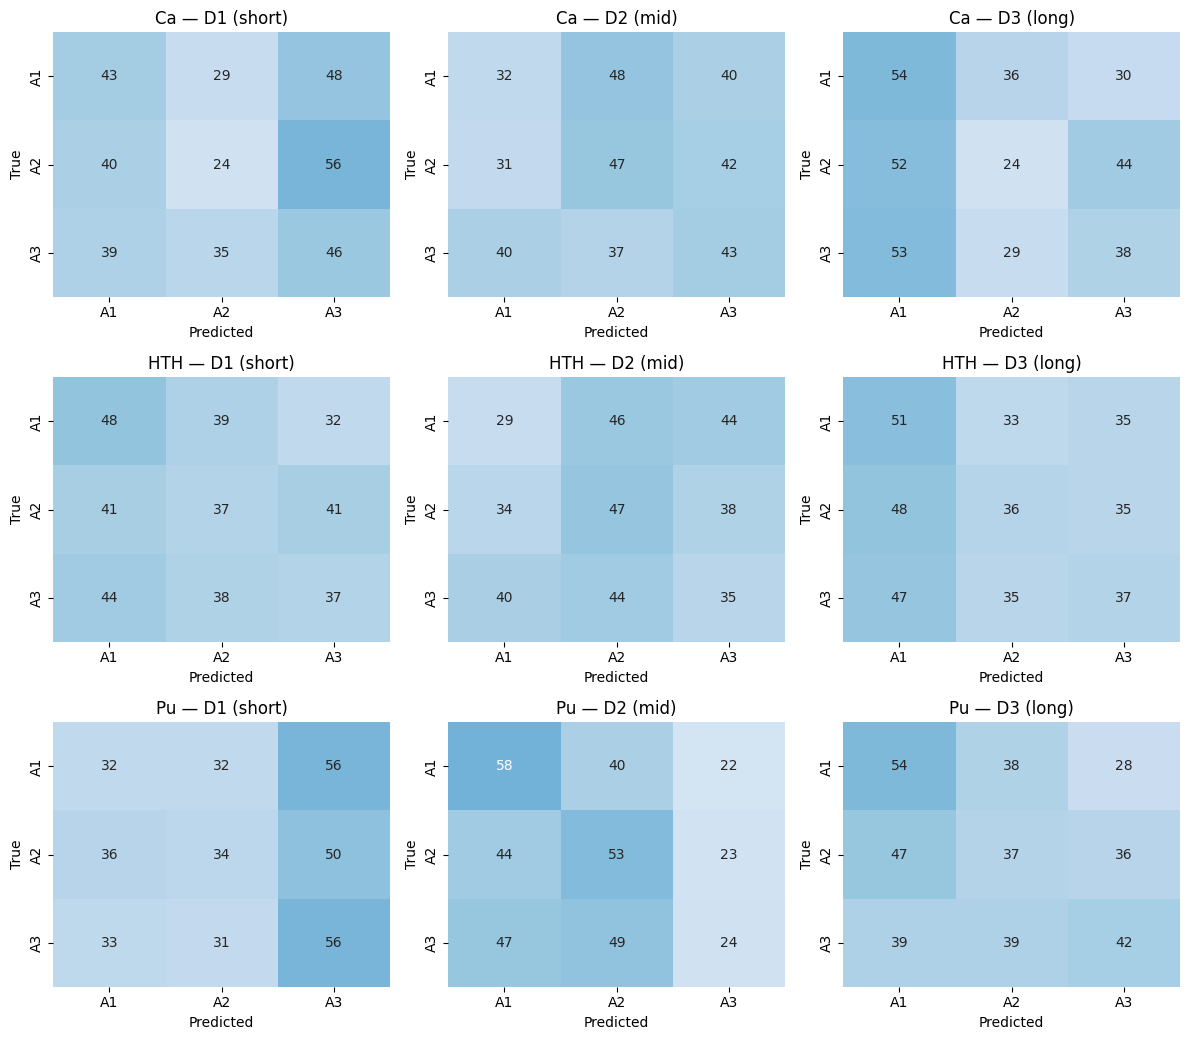

In [10]:
available_rois = sorted(conf_df['roi_name'].dropna().unique())
n_rois = len(available_rois)
n_delays = len(DELAY_BINS)

fig, axes = plt.subplots(n_rois, n_delays, figsize=(4 * n_delays, 3.5 * n_rois))
if n_rois == 1:
    axes = axes[np.newaxis, :]

for i, roi_name in enumerate(available_rois):
    for j, d in enumerate(DELAY_BINS):
        ax = axes[i, j]
        subset = conf_df[
            (conf_df['roi_name'] == roi_name) & (conf_df['delay_bin'] == d)
        ]
        if subset.empty:
            ax.set_visible(False)
            continue
        cm = subset.pivot(
            index='true_class', columns='pred_class', values='count'
        ).fillna(0)
        cm_norm = cm.div(cm.sum(axis=1), axis=0)
        sns.heatmap(
            cm_norm,
            annot=cm.astype(int),
            fmt='d',
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=False,
            xticklabels=['A1', 'A2', 'A3'],
            yticklabels=['A1', 'A2', 'A3'],
        )
        ax.set_title(f'{roi_name} — {DELAY_LABELS[d]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

plt.tight_layout()
plt.show()

---
## 7. Subject-level predictions

Check for outlier subjects driving group results.

In [11]:
pred_df['correct'] = (pred_df['y_true'] == pred_df['y_pred']).astype(int)

sub_acc = (
    pred_df.groupby(['sub_id', 'roi_name', 'delay_bin'])['correct']
    .mean()
    .reset_index()
    .rename(columns={'correct': 'accuracy'})
)

print('Per-subject accuracy distribution (pooled across ROIs and delay bins):')
print(sub_acc['accuracy'].describe().round(3))

Per-subject accuracy distribution (pooled across ROIs and delay bins):
count    1077.000
mean        0.340
std         0.221
min         0.000
25%         0.333
50%         0.333
75%         0.333
max         1.000
Name: accuracy, dtype: float64


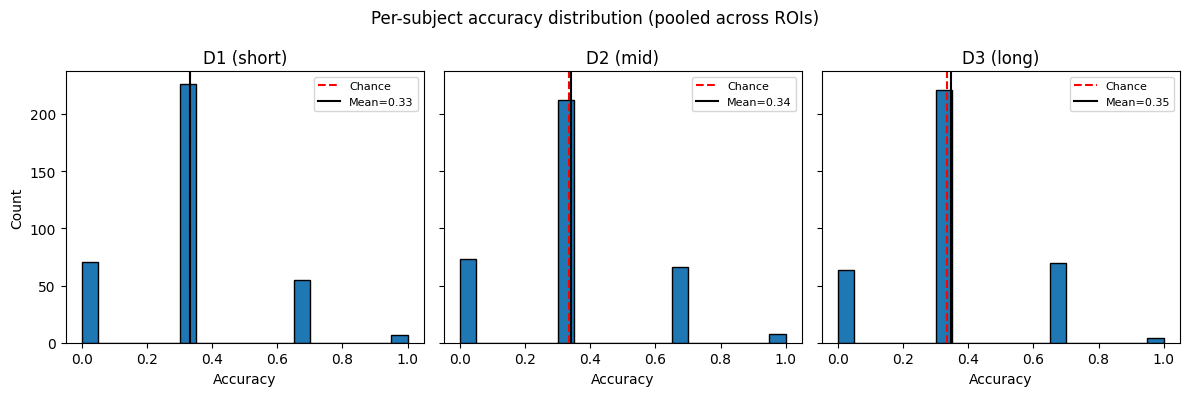

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
for ax, d in zip(axes, DELAY_BINS):
    data = sub_acc[sub_acc['delay_bin'] == d]['accuracy']
    ax.hist(data, bins=20, edgecolor='k')
    ax.axvline(CHANCE, color='r', linestyle='--', label='Chance')
    ax.axvline(data.mean(), color='k', linestyle='-', label=f'Mean={data.mean():.2f}')
    ax.set_title(DELAY_LABELS[d])
    ax.set_xlabel('Accuracy')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('Per-subject accuracy distribution (pooled across ROIs)')
plt.tight_layout()
plt.show()

---
## 8. Summary table

In [16]:
summary_cols = [
    'roi_name',
    'delay_bin',
    'n_subjects',
    'n_vox',
    'balanced_accuracy',
    'mean_auc',
    'f1_A1',
    'f1_A2',
    'f1_A3',
]

summary = (
    roi_df[summary_cols]
    .sort_values(['roi_name', 'delay_bin'])
    .round(3)
    .reset_index(drop=True)
)


summary

,roi_name,delay_bin,n_subjects,n_vox,balanced_accuracy,mean_auc,f1_A1,f1_A2,f1_A3
0,Ca,1,120,1272,0.314,0.485,0.355,0.231,0.341
1,Ca,2,120,1272,0.339,0.521,0.287,0.373,0.351
2,Ca,3,120,1272,0.322,0.480,0.387,0.230,0.328
3,HTH,1,119,34,0.342,0.513,0.381,0.318,0.323
4,HTH,2,119,34,0.311,0.497,0.261,0.367,0.297
5,HTH,3,119,34,0.347,0.500,0.385,0.323,0.327
6,Pu,1,120,1306,0.339,0.481,0.290,0.313,0.397
7,Pu,2,120,1306,0.375,0.508,0.431,0.405,0.254
8,Pu,3,120,1306,0.369,0.524,0.415,0.316,0.372
